# Waymo TFRecord EDA (Tutorial Format)

**Goal**
Build intuition about raw Waymo scenario structure and identify high-value training signals before cache generation.

**What this notebook does**
Runs lightweight EDA directly on one training and one validation TFRecord sample, then analyzes motion/map-derived features used by `download.py`.

**Inputs**
- Waymo GCS TFRecords (`training/`, `validation/`)
- Local analysis folder: `./waymo_eda_data`

**Output / interpretation**
- Split-level summary tables
- Scenario-level visualization
- Feature opportunity ranking and hard-case threshold calibration


### Execution Note

Outputs were trimmed for Git readability. Run all cells to regenerate full tables/plots from your environment.


## 1) Setup

**Goal**
Initialize dependencies and reusable helpers.

**What this section does**
Imports plotting/numeric libraries plus shared I/O helpers from `notebooks_lib.io_utils`.

**Inputs**
- Notebook environment with TensorFlow + Waymo proto support.

**Output / interpretation**
- Ready-to-run utility namespace for data pull and scenario iteration.


In [85]:
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from waymo_open_dataset.protos import scenario_pb2
from notebooks_lib.io_utils import (
    list_tfrecords,
    download_single_tfrecord,
    iter_scenarios,
    collect_split_stats,
)


In [86]:
# Paths reused from download.py
GCS_BASE = "gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario"
GCS_TRAIN_PATH = f"{GCS_BASE}/training/"
GCS_VAL_PATH = f"{GCS_BASE}/validation/"

LOCAL_DATA_DIR = Path("./waymo_eda_data")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE_INDEX = 0
VAL_FILE_INDEX = 0
FORCE_REDOWNLOAD = False
MAX_SCENARIOS_PER_SPLIT = 300  # Set to None to parse the entire TFRecord

TYPE_NAMES = {
    0: "TYPE_UNSET",
    1: "TYPE_VEHICLE",
    2: "TYPE_PEDESTRIAN",
    3: "TYPE_CYCLIST",
    4: "TYPE_OTHER",
}

print("TensorFlow:", tf.__version__)


TensorFlow: 2.12.0


## 2) Data Fetch

**Goal**
Fetch one train TFRecord and one validation TFRecord for quick exploratory analysis.

**What this section does**
Lists remote files, selects configured indices, downloads local copies (unless already cached).

**Inputs**
- GCS prefixes and index configuration.

**Output / interpretation**
- Local TFRecord paths used by downstream cells.


In [87]:
train_files = list_tfrecords(GCS_TRAIN_PATH)
val_files = list_tfrecords(GCS_VAL_PATH)

assert 0 <= TRAIN_FILE_INDEX < len(train_files), "TRAIN_FILE_INDEX is out of range"
assert 0 <= VAL_FILE_INDEX < len(val_files), "VAL_FILE_INDEX is out of range"

selected_train_gcs = train_files[TRAIN_FILE_INDEX]
selected_val_gcs = val_files[VAL_FILE_INDEX]

print("Selected training file:", selected_train_gcs)
print("Selected validation file:", selected_val_gcs)

train_tfrecord_path = download_single_tfrecord(selected_train_gcs, LOCAL_DATA_DIR, force=FORCE_REDOWNLOAD)
val_tfrecord_path = download_single_tfrecord(selected_val_gcs, LOCAL_DATA_DIR, force=FORCE_REDOWNLOAD)

print("Train local path:", train_tfrecord_path)
print("Val local path:", val_tfrecord_path)


Selected training file: gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/training/training.tfrecord-00000-of-01000
Selected validation file: gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/validation.tfrecord-00000-of-00150
Using existing file: waymo_eda_data/training.tfrecord-00000-of-01000
Using existing file: waymo_eda_data/validation.tfrecord-00000-of-00150
Train local path: waymo_eda_data/training.tfrecord-00000-of-01000
Val local path: waymo_eda_data/validation.tfrecord-00000-of-00150


## 3) Split Summaries

**Goal**
Compare basic composition between train and validation slices.

**What this section does**
Computes per-scenario counts, object type mix, and simple kinematic statistics.

**Inputs**
- Local train/val TFRecords
- `MAX_SCENARIOS_PER_SPLIT`

**Output / interpretation**
- Tables indicate whether both splits look consistent enough for model development.


In [88]:
train_stats = collect_split_stats(train_tfrecord_path, "train", max_scenarios=MAX_SCENARIOS_PER_SPLIT)
val_stats = collect_split_stats(val_tfrecord_path, "validation", max_scenarios=MAX_SCENARIOS_PER_SPLIT)


def split_summary(stats: dict) -> dict:
    return {
        "split": stats["split"],
        "scenarios_parsed": int(stats["scenario_count"]),
        "tracks_mean": float(np.nanmean(stats["tracks_per_scenario"])),
        "tracks_median": float(np.nanmedian(stats["tracks_per_scenario"])),
        "map_features_mean": float(np.nanmean(stats["map_features_per_scenario"])),
        "valid_state_ratio_mean": float(np.nanmean(stats["valid_ratio_per_scenario"])),
        "mean_speed_mps_mean": float(np.nanmean(stats["mean_speed_per_scenario"])),
    }


summary_df = pd.DataFrame([split_summary(train_stats), split_summary(val_stats)])
display(summary_df.round(4))


def object_type_table(stats: dict) -> pd.DataFrame:
    counter = stats["object_type_counter"]
    total = sum(counter.values())
    rows = []
    for type_id, count in sorted(counter.items()):
        rows.append({
            "split": stats["split"],
            "object_type": TYPE_NAMES.get(type_id, f"TYPE_{type_id}"),
            "count": int(count),
            "percent": (100.0 * count / total) if total > 0 else np.nan,
        })
    return pd.DataFrame(rows)


type_df = pd.concat([object_type_table(train_stats), object_type_table(val_stats)], ignore_index=True)
display(type_df.round(3))


2026-03-07 23:27:52.733713: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2026-03-07 23:27:55.317145: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


,split,scenarios_parsed,tracks_mean,tracks_median,map_features_mean,valid_state_ratio_mean,mean_speed_mps_mean
0,train,300,68.1133,54.5,341.7267,0.5572,3.8035
1,validation,286,64.0245,53.0,335.7308,0.5669,4.0127


,split,object_type,count,percent
0,train,TYPE_VEHICLE,17889,87.545
1,train,TYPE_PEDESTRIAN,2409,11.789
2,train,TYPE_CYCLIST,136,0.666
3,validation,TYPE_VEHICLE,16377,89.438
4,validation,TYPE_PEDESTRIAN,1783,9.737
5,validation,TYPE_CYCLIST,151,0.825


## 4) Scenario Visualization

**Goal**
Inspect one scenario qualitatively before feature engineering.

**What this section does**
Plots map polylines and track trajectories to validate coordinate conventions and coverage.

**Inputs**
- `example_scenario` from split stats.

**Output / interpretation**
- Quick sanity check that scene geometry and trajectories are parsed correctly.


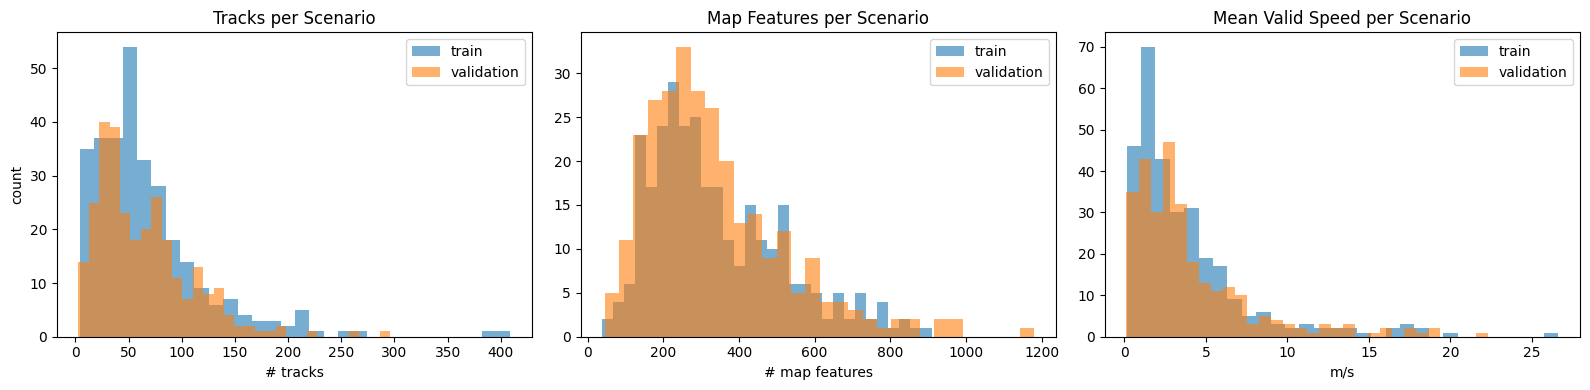

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_stats["tracks_per_scenario"], bins=30, alpha=0.6, label="train")
axes[0].hist(val_stats["tracks_per_scenario"], bins=30, alpha=0.6, label="validation")
axes[0].set_title("Tracks per Scenario")
axes[0].set_xlabel("# tracks")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].hist(train_stats["map_features_per_scenario"], bins=30, alpha=0.6, label="train")
axes[1].hist(val_stats["map_features_per_scenario"], bins=30, alpha=0.6, label="validation")
axes[1].set_title("Map Features per Scenario")
axes[1].set_xlabel("# map features")
axes[1].legend()

axes[2].hist(train_stats["mean_speed_per_scenario"], bins=30, alpha=0.6, label="train")
axes[2].hist(val_stats["mean_speed_per_scenario"], bins=30, alpha=0.6, label="validation")
axes[2].set_title("Mean Valid Speed per Scenario")
axes[2].set_xlabel("m/s")
axes[2].legend()

plt.tight_layout()
plt.show()


In [90]:
TRACK_COLORS = {
    1: "#1f77b4",  # vehicle
    2: "#2ca02c",  # pedestrian
    3: "#ff7f0e",  # cyclist
    4: "#d62728",  # other
}


def _feature_points(feature) -> np.ndarray:
    feature_name = feature.WhichOneof("feature_data")
    if feature_name is None:
        return np.zeros((0, 2), dtype=np.float32)

    geom = getattr(feature, feature_name)
    for attr in ("polyline", "polygon"):
        pts = getattr(geom, attr, None)
        if pts is not None and len(pts) > 0:
            return np.array([(p.x, p.y) for p in pts], dtype=np.float32)

    return np.zeros((0, 2), dtype=np.float32)


def plot_scenario_topdown(scenario: scenario_pb2.Scenario, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 8))

    for map_feature in scenario.map_features:
        pts = _feature_points(map_feature)
        if pts.shape[0] >= 2:
            ax.plot(pts[:, 0], pts[:, 1], color="#BBBBBB", linewidth=0.6, alpha=0.45, zorder=1)

    for track in scenario.tracks:
        xy = [(s.center_x, s.center_y) for s in track.states if s.valid]
        if len(xy) < 2:
            continue

        xy = np.asarray(xy, dtype=np.float32)
        color = TRACK_COLORS.get(int(track.object_type), "#7f7f7f")
        ax.plot(xy[:, 0], xy[:, 1], color=color, linewidth=1.0, alpha=0.85, zorder=2)
        ax.scatter(xy[-1, 0], xy[-1, 1], color=color, s=8, alpha=0.9, zorder=3)

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{title} | scenario_id={scenario.scenario_id}")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


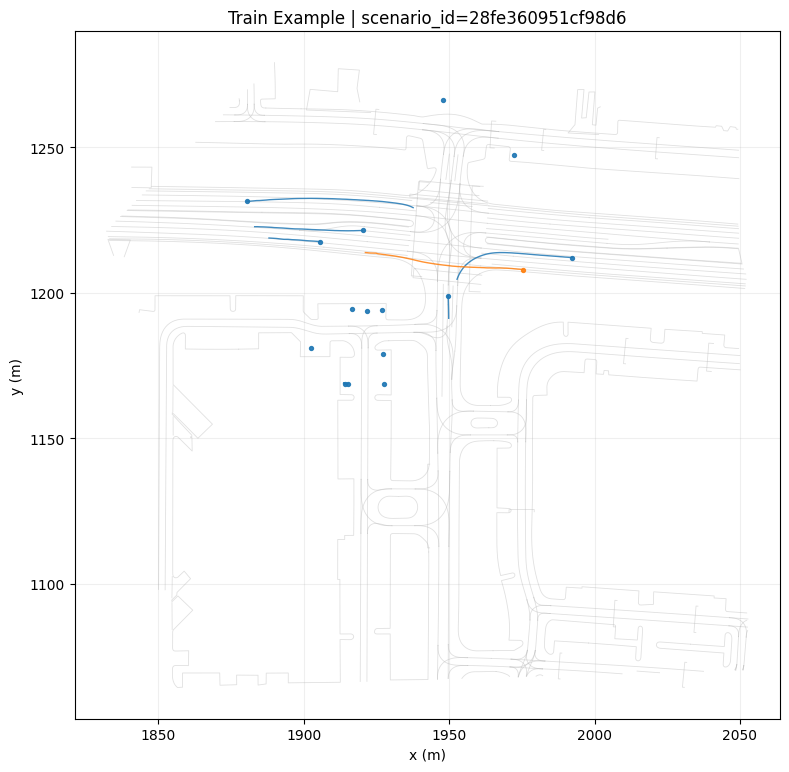

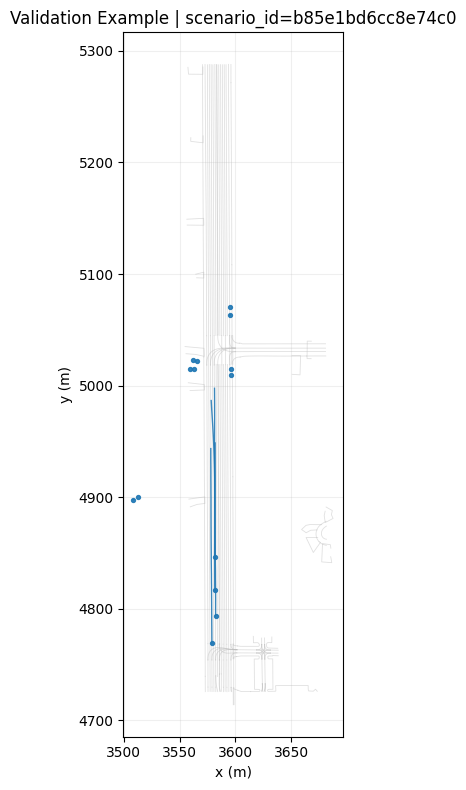

In [91]:
plot_scenario_topdown(train_stats["example_scenario"], "Train Example")
plot_scenario_topdown(val_stats["example_scenario"], "Validation Example")


## 5) Training-Signal Deep Dive

**Goal**
Quantify feature distributions used for training-time decisions.

**What this section does**
Builds per-track and per-anchor records, summarizes dynamics/map context, and estimates hard-case prevalence.

**Inputs**
- Scenario iterator
- Anchor-time conventions (`t=10`, horizon `80`)

**Output / interpretation**
- Feature ranking and threshold diagnostics to justify preprocessing choices in `download.py`.


In [92]:
CURRENT_TIME_INDEX = 10
FUTURE_STEPS = 80
DT = 0.1
NEIGHBOR_RADII = (10.0, 20.0, 40.0)

def wrap_angle(theta: np.ndarray | float) -> np.ndarray | float:
    return np.arctan2(np.sin(theta), np.cos(theta))


def scenario_map_points(scenario: scenario_pb2.Scenario) -> dict[str, np.ndarray]:
    lane_points = []
    edge_points = []
    map_kind_counter = Counter()

    for map_feature in scenario.map_features:
        kind = map_feature.WhichOneof("feature_data")
        if kind is None:
            continue
        map_kind_counter[kind] += 1

        geom = getattr(map_feature, kind)
        pts = None
        if hasattr(geom, "polyline") and len(geom.polyline) > 0:
            pts = np.array([(p.x, p.y) for p in geom.polyline], dtype=np.float32)
        elif hasattr(geom, "polygon") and len(geom.polygon) > 0:
            pts = np.array([(p.x, p.y) for p in geom.polygon], dtype=np.float32)

        if pts is None or pts.shape[0] == 0:
            continue

        if kind in {"lane", "road_line"}:
            lane_points.append(pts)
        elif kind == "road_edge":
            edge_points.append(pts)

    lane_points = np.concatenate(lane_points, axis=0) if lane_points else np.zeros((0, 2), dtype=np.float32)
    edge_points = np.concatenate(edge_points, axis=0) if edge_points else np.zeros((0, 2), dtype=np.float32)

    return {
        "lane_points": lane_points,
        "edge_points": edge_points,
        "map_kind_counter": map_kind_counter,
    }


def nearest_distance(point_xy: np.ndarray, points_xy: np.ndarray) -> float:
    if points_xy.shape[0] == 0:
        return np.nan
    deltas = points_xy - point_xy[None, :]
    dist2 = np.sum(deltas * deltas, axis=1)
    return float(np.sqrt(np.min(dist2)))


def parse_lane_state_name(lane_state) -> str:
    try:
        field = lane_state.DESCRIPTOR.fields_by_name.get("state")
        if field is None or field.enum_type is None:
            return str(int(lane_state.state))
        enum_val = field.enum_type.values_by_number.get(int(lane_state.state))
        return enum_val.name if enum_val is not None else str(int(lane_state.state))
    except Exception:
        return str(int(getattr(lane_state, "state", -1)))


In [93]:
def collect_training_eda_records(tfrecord_path: Path, split_name: str, max_scenarios: int | None = None) -> dict:
    scenario_rows = []
    track_rows = []
    anchor_rows = []
    map_kind_counter = Counter()
    lane_state_counter = Counter()

    for scenario in iter_scenarios(tfrecord_path, max_scenarios=max_scenarios):
        map_cache = scenario_map_points(scenario)
        map_kind_counter.update(map_cache["map_kind_counter"])

        for dyn_state in scenario.dynamic_map_states:
            for lane_state in dyn_state.lane_states:
                lane_state_counter[parse_lane_state_name(lane_state)] += 1

        type_counter = Counter(int(t.object_type) for t in scenario.tracks)
        scenario_rows.append({
            "split": split_name,
            "scenario_id": scenario.scenario_id,
            "num_tracks": len(scenario.tracks),
            "num_map_features": len(scenario.map_features),
            "num_dynamic_map_states": len(scenario.dynamic_map_states),
            "num_vehicles": int(type_counter.get(1, 0)),
            "num_pedestrians": int(type_counter.get(2, 0)),
            "num_cyclists": int(type_counter.get(3, 0)),
            "num_others": int(type_counter.get(4, 0)),
        })

        for track_idx, track in enumerate(scenario.tracks):
            states = track.states
            T = len(states)
            if T == 0:
                continue

            x = np.array([s.center_x for s in states], dtype=np.float32)
            y = np.array([s.center_y for s in states], dtype=np.float32)
            heading = np.array([s.heading for s in states], dtype=np.float32)
            vx = np.array([s.velocity_x for s in states], dtype=np.float32)
            vy = np.array([s.velocity_y for s in states], dtype=np.float32)
            valid = np.array([bool(s.valid) for s in states], dtype=bool)

            speed = np.hypot(vx, vy)
            valid_speed = speed[valid]

            accel = np.full(T, np.nan, dtype=np.float32)
            yaw_rate = np.full(T, np.nan, dtype=np.float32)
            if T > 1:
                valid_pair = valid[1:] & valid[:-1]
                speed_diff = speed[1:] - speed[:-1]
                heading_diff = wrap_angle(heading[1:] - heading[:-1])
                accel[1:][valid_pair] = speed_diff[valid_pair] / DT
                yaw_rate[1:][valid_pair] = heading_diff[valid_pair] / DT

            track_rows.append({
                "split": split_name,
                "scenario_id": scenario.scenario_id,
                "track_idx": int(track_idx),
                "object_type": TYPE_NAMES.get(int(track.object_type), f"TYPE_{int(track.object_type)}"),
                "valid_ratio": float(valid.mean()),
                "valid_steps": int(valid.sum()),
                "mean_speed": float(np.nanmean(valid_speed)) if valid_speed.size else np.nan,
                "p95_speed": float(np.nanpercentile(valid_speed, 95)) if valid_speed.size else np.nan,
                "mean_abs_accel": float(np.nanmean(np.abs(accel))) if np.isfinite(accel).any() else np.nan,
                "mean_abs_yaw_rate": float(np.nanmean(np.abs(yaw_rate))) if np.isfinite(yaw_rate).any() else np.nan,
            })

            t = CURRENT_TIME_INDEX
            if t >= T or (not valid[t]):
                continue

            future_end = min(T, t + 1 + FUTURE_STEPS)
            future_valid_mask = valid[t + 1:future_end]
            future_valid_steps = int(future_valid_mask.sum())

            final_displacement = np.nan
            if future_valid_steps > 0:
                valid_offsets = np.where(future_valid_mask)[0]
                last_future = t + 1 + int(valid_offsets[-1])
                final_displacement = float(np.hypot(x[last_future] - x[t], y[last_future] - y[t]))

            anchor_xy = np.array([x[t], y[t]], dtype=np.float32)
            neighbor_distances = []
            for other_idx, other_track in enumerate(scenario.tracks):
                if other_idx == track_idx:
                    continue
                if t >= len(other_track.states):
                    continue
                other_state = other_track.states[t]
                if not other_state.valid:
                    continue
                d = math.hypot(other_state.center_x - anchor_xy[0], other_state.center_y - anchor_xy[1])
                neighbor_distances.append(d)

            neighbor_distances = np.asarray(neighbor_distances, dtype=np.float32)
            neighbor_counts = {
                f"neighbor_count_{int(r)}m": int(np.sum(neighbor_distances <= r)) if neighbor_distances.size else 0
                for r in NEIGHBOR_RADII
            }

            lane_dist = nearest_distance(anchor_xy, map_cache["lane_points"])
            edge_dist = nearest_distance(anchor_xy, map_cache["edge_points"])

            anchor_speed = float(speed[t])
            anchor_accel = float(accel[t]) if np.isfinite(accel[t]) else np.nan
            anchor_yaw_rate = float(yaw_rate[t]) if np.isfinite(yaw_rate[t]) else np.nan
            anchor_curvature = anchor_yaw_rate / max(anchor_speed, 1e-2) if np.isfinite(anchor_yaw_rate) else np.nan

            anchor_rows.append({
                "split": split_name,
                "scenario_id": scenario.scenario_id,
                "track_idx": int(track_idx),
                "object_type": TYPE_NAMES.get(int(track.object_type), f"TYPE_{int(track.object_type)}"),
                "anchor_speed": anchor_speed,
                "anchor_accel": anchor_accel,
                "anchor_yaw_rate": anchor_yaw_rate,
                "anchor_curvature": anchor_curvature,
                "future_valid_steps": future_valid_steps,
                "has_full_future_80": int(future_valid_steps == FUTURE_STEPS),
                "final_displacement": final_displacement,
                "nearest_lane_dist": lane_dist,
                "nearest_edge_dist": edge_dist,
                **neighbor_counts,
            })

    scenario_df = pd.DataFrame(scenario_rows)
    track_df = pd.DataFrame(track_rows)
    anchor_df = pd.DataFrame(anchor_rows)

    return {
        "scenario_df": scenario_df,
        "track_df": track_df,
        "anchor_df": anchor_df,
        "map_kind_counter": map_kind_counter,
        "lane_state_counter": lane_state_counter,
    }


## 6) Aggregate Diagnostics and Recommendations

**Goal**
Convert raw feature distributions into model-facing recommendations.

**What this section does**
Produces grouped tables/plots and a candidate feature opportunity matrix.

**Inputs**
- Deep EDA dataframes/counters.

**Output / interpretation**
- Actionable signals for feature transforms and hard-case sampling heuristics.


In [94]:
train_deep = collect_training_eda_records(
    train_tfrecord_path, "train", max_scenarios=MAX_SCENARIOS_PER_SPLIT
)
val_deep = collect_training_eda_records(
    val_tfrecord_path, "validation", max_scenarios=MAX_SCENARIOS_PER_SPLIT
)

deep_scenario_df = pd.concat([train_deep["scenario_df"], val_deep["scenario_df"]], ignore_index=True)
deep_track_df = pd.concat([train_deep["track_df"], val_deep["track_df"]], ignore_index=True)
deep_anchor_df = pd.concat([train_deep["anchor_df"], val_deep["anchor_df"]], ignore_index=True)

print("Scenario rows:", len(deep_scenario_df))
print("Track rows:", len(deep_track_df))
print("Anchor rows:", len(deep_anchor_df))


2026-03-07 23:27:58.785436: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2026-03-07 23:28:17.247108: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


Scenario rows: 586
Track rows: 38745
Anchor rows: 20392


In [95]:
scenario_summary = (
    deep_scenario_df.groupby("split", as_index=False)[[
        "num_tracks",
        "num_map_features",
        "num_dynamic_map_states",
        "num_vehicles",
        "num_pedestrians",
        "num_cyclists",
    ]]
    .mean()
)
display(scenario_summary.round(2))

track_type_summary = (
    deep_track_df.groupby(["split", "object_type"], as_index=False)[[
        "valid_ratio",
        "mean_speed",
        "p95_speed",
        "mean_abs_accel",
        "mean_abs_yaw_rate",
    ]]
    .mean()
)
display(track_type_summary.round(3))

anchor_summary = (
    deep_anchor_df.groupby("split", as_index=False)[[
        "future_valid_steps",
        "has_full_future_80",
        "final_displacement",
        "anchor_speed",
        "anchor_accel",
        "anchor_yaw_rate",
        "nearest_lane_dist",
        "nearest_edge_dist",
        "neighbor_count_10m",
        "neighbor_count_20m",
        "neighbor_count_40m",
    ]]
    .mean()
)
display(anchor_summary.round(3))


,split,num_tracks,num_map_features,num_dynamic_map_states,num_vehicles,num_pedestrians,num_cyclists
0,train,68.11,341.73,91.0,59.63,8.03,0.45
1,validation,64.02,335.73,91.0,57.26,6.23,0.53


,split,object_type,valid_ratio,mean_speed,p95_speed,mean_abs_accel,mean_abs_yaw_rate
0,train,TYPE_CYCLIST,0.506,3.407,4.446,5.194,0.962
1,train,TYPE_PEDESTRIAN,0.379,1.005,1.615,2.732,1.787
2,train,TYPE_VEHICLE,0.540,2.871,3.649,1.626,0.099
3,validation,TYPE_CYCLIST,0.507,3.604,4.554,5.378,1.023
4,validation,TYPE_PEDESTRIAN,0.363,1.090,1.741,2.978,1.723
5,validation,TYPE_VEHICLE,0.564,3.199,4.052,1.779,0.092


,split,future_valid_steps,has_full_future_80,final_displacement,anchor_speed,anchor_accel,anchor_yaw_rate,nearest_lane_dist,nearest_edge_dist,neighbor_count_10m,neighbor_count_20m,neighbor_count_40m
0,train,56.966,0.471,14.663,2.640,0.002,-0.005,5.857,7.293,2.556,7.713,20.943
1,validation,59.163,0.510,15.596,2.772,0.247,-0.006,5.622,6.837,2.367,7.429,20.453


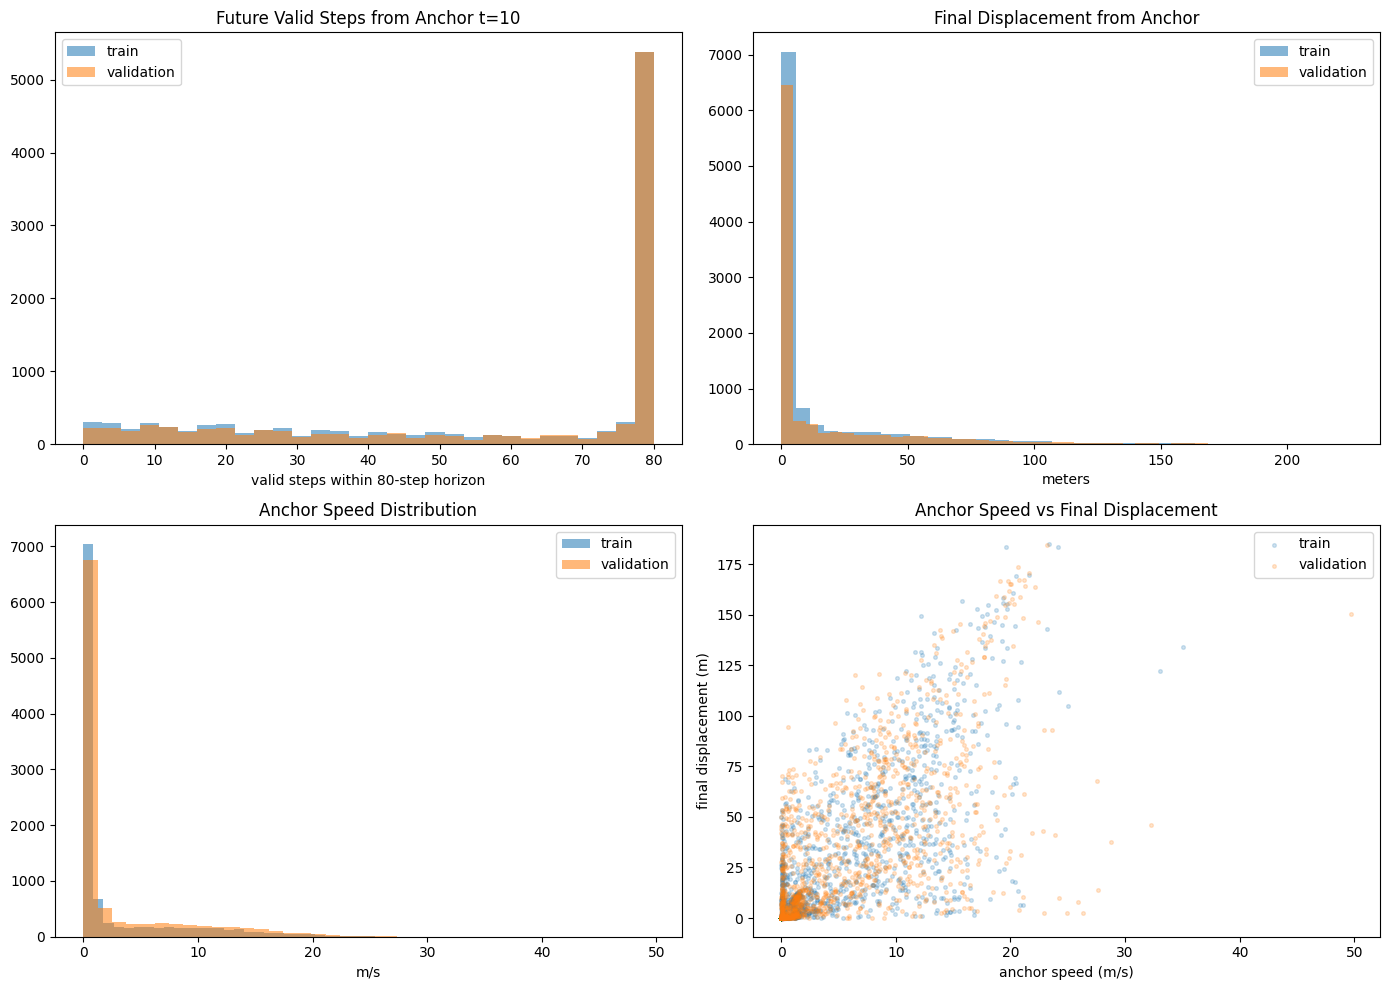

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for split, color in [("train", "#1f77b4"), ("validation", "#ff7f0e")]:
    df = deep_anchor_df[deep_anchor_df["split"] == split]
    axes[0, 0].hist(df["future_valid_steps"], bins=30, alpha=0.55, label=split, color=color)
    axes[0, 1].hist(df["final_displacement"], bins=40, alpha=0.55, label=split, color=color)
    axes[1, 0].hist(df["anchor_speed"], bins=40, alpha=0.55, label=split, color=color)

axes[0, 0].set_title("Future Valid Steps from Anchor t=10")
axes[0, 0].set_xlabel("valid steps within 80-step horizon")
axes[0, 0].legend()

axes[0, 1].set_title("Final Displacement from Anchor")
axes[0, 1].set_xlabel("meters")
axes[0, 1].legend()

axes[1, 0].set_title("Anchor Speed Distribution")
axes[1, 0].set_xlabel("m/s")
axes[1, 0].legend()

sample_df = deep_anchor_df[["split", "anchor_speed", "final_displacement"]].dropna()
for split, color in [("train", "#1f77b4"), ("validation", "#ff7f0e")]:
    df = sample_df[sample_df["split"] == split]
    if len(df) == 0:
        continue
    draw = df.sample(min(3000, len(df)), random_state=42)
    axes[1, 1].scatter(draw["anchor_speed"], draw["final_displacement"], s=7, alpha=0.2, color=color, label=split)

axes[1, 1].set_title("Anchor Speed vs Final Displacement")
axes[1, 1].set_xlabel("anchor speed (m/s)")
axes[1, 1].set_ylabel("final displacement (m)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [97]:
def counter_to_df(counter: Counter, split: str, col_name: str) -> pd.DataFrame:
    rows = [{"split": split, col_name: k, "count": int(v)} for k, v in counter.items()]
    if not rows:
        return pd.DataFrame(columns=["split", col_name, "count", "percent"])
    out = pd.DataFrame(rows)
    out["percent"] = 100.0 * out["count"] / out["count"].sum()
    return out.sort_values("count", ascending=False)

map_kind_df = pd.concat([
    counter_to_df(train_deep["map_kind_counter"], "train", "map_feature_kind"),
    counter_to_df(val_deep["map_kind_counter"], "validation", "map_feature_kind"),
], ignore_index=True)

lane_state_df = pd.concat([
    counter_to_df(train_deep["lane_state_counter"], "train", "lane_state"),
    counter_to_df(val_deep["lane_state_counter"], "validation", "lane_state"),
], ignore_index=True)

print("Map feature coverage by kind")
display(map_kind_df)

print("Dynamic lane state coverage")
display(lane_state_df)


Map feature coverage by kind


,split,map_feature_kind,count,percent
0,train,lane,65117,63.517626
1,train,road_edge,12872,12.555844
2,train,road_line,11794,11.504321
3,train,driveway,7620,7.432841
4,train,crosswalk,2416,2.356659
5,train,speed_bump,1578,1.539242
6,train,stop_sign,1121,1.093467
7,validation,lane,59976,62.462638
8,validation,road_edge,11908,12.401712
9,validation,road_line,11177,11.640405


Dynamic lane state coverage


,split,lane_state,count,percent
0,train,LANE_STATE_STOP,62017,34.949985
1,train,LANE_STATE_UNKNOWN,41194,23.215081
2,train,LANE_STATE_GO,35916,20.240638
3,train,LANE_STATE_ARROW_STOP,25598,14.425878
4,train,LANE_STATE_CAUTION,5918,3.335118
5,train,LANE_STATE_ARROW_GO,4992,2.813266
6,train,LANE_STATE_ARROW_CAUTION,1810,1.020034
7,validation,LANE_STATE_STOP,61449,36.895448
8,validation,LANE_STATE_UNKNOWN,37717,22.646188
9,validation,LANE_STATE_GO,37715,22.644987


In [98]:
candidate_cols = [
    "anchor_speed",
    "anchor_accel",
    "anchor_yaw_rate",
    "anchor_curvature",
    "nearest_lane_dist",
    "nearest_edge_dist",
    "neighbor_count_10m",
    "neighbor_count_20m",
    "neighbor_count_40m",
]

target_col = "final_displacement"
work_df = deep_anchor_df[candidate_cols + [target_col]].copy()

used_in_download = {
    "anchor_speed": True,
    "anchor_accel": False,
    "anchor_yaw_rate": False,
    "anchor_curvature": False,
    "nearest_lane_dist": True,
    "nearest_edge_dist": True,
    "neighbor_count_10m": False,
    "neighbor_count_20m": False,
    "neighbor_count_40m": False,
}

transform_hints = {
    "anchor_speed": "log1p(speed) + clip at p99",
    "anchor_accel": "clip symmetric (p1, p99)",
    "anchor_yaw_rate": "sin/cos(yaw_rate * dt) for bounded encoding",
    "anchor_curvature": "tanh(curvature) to stabilize tails",
    "nearest_lane_dist": "log1p(distance)",
    "nearest_edge_dist": "log1p(distance) + near-edge binary flag",
    "neighbor_count_10m": "bucketize {0,1,2,3,4+}",
    "neighbor_count_20m": "bucketize {0,1-2,3-5,6+}",
    "neighbor_count_40m": "z-score + clip",
}

rows = []
for col in candidate_cols:
    valid_mask = work_df[[col, target_col]].notna().all(axis=1)
    coverage = float(work_df[col].notna().mean())
    corr = np.nan
    if valid_mask.sum() > 10:
        corr = float(np.corrcoef(work_df.loc[valid_mask, col], work_df.loc[valid_mask, target_col])[0, 1])

    lo = float(np.nanpercentile(work_df[col], 1)) if work_df[col].notna().any() else np.nan
    hi = float(np.nanpercentile(work_df[col], 99)) if work_df[col].notna().any() else np.nan

    rows.append({
        "feature": col,
        "used_in_download_py": used_in_download[col],
        "non_null_ratio": coverage,
        "corr_with_final_displacement": corr,
        "abs_corr": abs(corr) if np.isfinite(corr) else np.nan,
        "p01": lo,
        "p99": hi,
        "suggested_transform": transform_hints[col],
    })

feature_opportunity_df = pd.DataFrame(rows).sort_values(["used_in_download_py", "abs_corr"], ascending=[True, False])
display(feature_opportunity_df.round(4))


,feature,used_in_download_py,non_null_ratio,corr_with_final_displacement,abs_corr,p01,p99,suggested_transform
6,neighbor_count_10m,False,1.0000,-0.2584,0.2584,0.0000,11.0000,"bucketize {0,1,2,3,4+}"
7,neighbor_count_20m,False,1.0000,-0.2308,0.2308,0.0000,35.0000,"bucketize {0,1-2,3-5,6+}"
8,neighbor_count_40m,False,1.0000,-0.2044,0.2044,1.0000,95.0000,z-score + clip
1,anchor_accel,False,0.9775,0.0525,0.0525,-8.8149,10.1985,"clip symmetric (p1, p99)"
3,anchor_curvature,False,0.9775,0.0048,0.0048,-2.2130,1.8059,tanh(curvature) to stabilize tails
2,anchor_yaw_rate,False,0.9775,0.0041,0.0041,-0.6013,0.6366,sin/cos(yaw_rate * dt) for bounded encoding
0,anchor_speed,True,1.0000,0.7716,0.7716,0.0000,20.1342,log1p(speed) + clip at p99
4,nearest_lane_dist,True,1.0000,-0.2924,0.2924,0.0494,40.9257,log1p(distance)
5,nearest_edge_dist,True,1.0000,-0.0749,0.0749,0.5495,38.4339,log1p(distance) + near-edge binary flag


In [99]:
# Calibrate hard-case thresholds currently used in download.py
HIGH_SPEED_STEP_THRESHOLD = 2.6  # in x/y delta units from download.py
EDGE_NEAR_THRESHOLD_M = 6.0

hard_case_df = deep_anchor_df.copy()
hard_case_df["is_high_speed"] = hard_case_df["anchor_speed"] >= HIGH_SPEED_STEP_THRESHOLD
hard_case_df["is_near_edge"] = hard_case_df["nearest_edge_dist"] <= EDGE_NEAR_THRESHOLD_M
hard_case_df["is_hard_case"] = hard_case_df[["is_high_speed", "is_near_edge"]].any(axis=1)

hard_case_summary = hard_case_df.groupby("split", as_index=False)[["is_high_speed", "is_near_edge", "is_hard_case"]].mean()
hard_case_pct = hard_case_summary.copy()
pct_cols = ["is_high_speed", "is_near_edge", "is_hard_case"]
hard_case_pct[pct_cols] = 100.0 * hard_case_pct[pct_cols]
display(hard_case_pct.round(2))

impact_df = hard_case_df.groupby(["split", "is_hard_case"], as_index=False)[["future_valid_steps", "final_displacement"]].mean()
display(impact_df.round(3))


,split,is_high_speed,is_near_edge,is_hard_case
0,train,24.69,60.52,69.81
1,validation,25.82,62.66,72.44


,split,is_hard_case,future_valid_steps,final_displacement
0,train,False,56.547,2.045
1,train,True,57.147,20.107
2,validation,False,59.078,3.131
3,validation,True,59.196,20.323


In [1]:
import numpy as np
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2
import matplotlib.pyplot as plt

def analyze_map_and_traffic_schema(tfrecord_path: str, max_scenarios: int = 50):
    dataset = tf.data.TFRecordDataset([tfrecord_path])
    
    polyline_lengths = []
    polylines_per_scenario = []
    
    # Traffic light validation counters
    total_light_states = 0
    matched_light_states = 0
    
    print(f"Analyzing up to {max_scenarios} scenarios...")
    
    for idx, bytes_example in enumerate(dataset.as_numpy_iterator()):
        if idx >= max_scenarios:
            break
            
        scenario = scenario_pb2.Scenario.FromString(bytes_example)
        
        # 1. Analyze Map Polylines
        map_features = scenario.map_features
        polylines_per_scenario.append(len(map_features))
        
        valid_lane_ids = set()
        for feature in map_features:
            feature_type = feature.WhichOneof("feature_data")
            if feature_type is None:
                continue
                
            data = getattr(feature, feature_type)
            if hasattr(data, 'polyline'):
                polyline_lengths.append(len(data.polyline))
            
            # Track IDs that represent drivable lanes
            if feature_type == 'lane':
                valid_lane_ids.add(feature.id)
                
        # 2. Analyze Traffic Light Links
        # Check the current timestep (index 10) for traffic light IDs
        if len(scenario.dynamic_map_states) > 10:
            current_signal_state = scenario.dynamic_map_states[10]
            for state in current_signal_state.lane_states:
                total_light_states += 1
                if state.lane in valid_lane_ids:
                    matched_light_states += 1

    # Print Report
    print("\n--- Map Polyline Budget (M) ---")
    print(f"Min polylines per scenario: {np.min(polylines_per_scenario)}")
    print(f"Max polylines per scenario: {np.max(polylines_per_scenario)}")
    print(f"95th percentile (Suggested M): {int(np.percentile(polylines_per_scenario, 95))}")
    
    print("\n--- Points Per Polyline Budget (P) ---")
    print(f"Min points in a polyline: {np.min(polyline_lengths)}")
    print(f"Max points in a polyline: {np.max(polyline_lengths)}")
    print(f"95th percentile: {int(np.percentile(polyline_lengths, 95))}")
    # Calculation for spatial coverage
    print(f"Note: 95th percentile length covers ~{int(np.percentile(polyline_lengths, 95)) * 0.5} meters.")
    
    print("\n--- Traffic Light ID Linkage ---")
    match_rate = (matched_light_states / total_light_states * 100) if total_light_states > 0 else 0
    print(f"Total active traffic lights analyzed: {total_light_states}")
    print(f"Traffic lights successfully matched to a lane ID: {matched_light_states} ({match_rate:.2f}%)")
    if match_rate < 100.0:
        print("WARNING: Some traffic light IDs do not match any lane ID in the map features. You must handle default/unmatched states in the map_signal tensor.")

# Usage (replace with an actual local tfrecord path downloaded by download.py)
analyze_map_and_traffic_schema("./waymo_val_cache/uncompressed_scenario_validation_validation.tfrecord-00000-of-00150")

2026-03-12 16:07:11.406548: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-12 16:07:11.433658: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-12 16:07:11.434343: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 16:07:12.207479: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Analyzing up to 50 scenarios...

--- Map Polyline Budget (M) ---
Min polylines per scenario: 45
Max polylines per scenario: 821
95th percentile (Suggested M): 576

--- Points Per Polyline Budget (P) ---
Min points in a polyline: 1
Max points in a polyline: 1134
95th percentile: 252
Note: 95th percentile length covers ~126.0 meters.

--- Traffic Light ID Linkage ---
Total active traffic lights analyzed: 270
Traffic lights successfully matched to a lane ID: 270 (100.00%)


2026-03-12 16:07:14.312556: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2b:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-12 16:07:14.358730: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
